In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import src.spaces as spaces

from src.training import (
    train,
    train_resnet,
    loss_fn_da,
    loss_fn_fa,
    loss_fn_da_resnet,
    loss_fn_fa_resnet,
    DEFAULT_CONFIG,
    DEFAULT_CONFIG_RESNET,
)
from src.teacher import (
    make_wi_particles,
    make_arbitrary_particles,
    make_wi_particles_resnet,
    make_arbitrary_particles_resnet,
)
from src.utils import plot_loss_curves, plot_training_curves

# Loss décroissante avec le nombre de paramètres

Ce notebook vérifie que la loss finale décroît bien lorsqu'on augmente :
- **N** (nombre de neurones) pour les réseaux de neurones classiques ;
- **L** (profondeur) pour les ResNets.

Chaque figure présente les courbes **vanilla**, **DA** et **FA** avec leurs barres d'erreur (écart-type sur `N_REPS` répétitions).
Les fonctions de plot acceptent un paramètre booléen `save_pdf` (défaut `False`) pour enregistrer la figure en PDF.

---
## 1. Réseau de neurones classique — setup **matrix**

In [ ]:
spaces.SETUP = spaces.make_setup_matrix()
jax.clear_caches()

N_VALUES = [5, 10, 50, 100, 500]
N_REPS   = 3
CONFIG   = {**DEFAULT_CONFIG, "T": 2.0, "gr": 5}

### 1.1 Teacher WI — setup matrix

In [6]:
teacher_wi = make_wi_particles()

results_nn_matrix_wi = {"vanilla": [], "DA": [], "FA": []}

for N in N_VALUES:
    for name in results_nn_matrix_wi:
        results_nn_matrix_wi[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train(teacher_wi, N, jax.random.fold_in(key, 0), CONFIG, "si")
        results_nn_matrix_wi["vanilla"][-1].append(h["losses"][-1])

        h = train(teacher_wi, N, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da)
        results_nn_matrix_wi["DA"][-1].append(h["losses"][-1])

        h = train(teacher_wi, N, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa)
        results_nn_matrix_wi["FA"][-1].append(h["losses"][-1])

    print(f"N={N} done")

N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


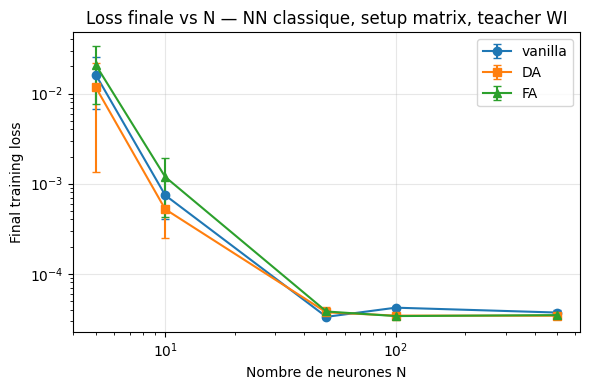

In [7]:
def plot_nn_loss_vs_N_matrix_wi(save_pdf=False):
    plot_loss_curves(
        N_VALUES,
        results_nn_matrix_wi,
        xlabel="Nombre de neurones N",
        title="Loss finale vs N — NN classique, setup matrix, teacher WI",
        save_pdf=save_pdf,
    )

plot_nn_loss_vs_N_matrix_wi(save_pdf=False)

### 1.2 Teacher arbitraire — setup matrix

In [8]:
teacher_arb = make_arbitrary_particles()

results_nn_matrix_arb = {"vanilla": [], "DA": [], "FA": []}

for N in N_VALUES:
    for name in results_nn_matrix_arb:
        results_nn_matrix_arb[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train(teacher_arb, N, jax.random.fold_in(key, 0), CONFIG, "si")
        results_nn_matrix_arb["vanilla"][-1].append(h["losses"][-1])

        h = train(teacher_arb, N, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da)
        results_nn_matrix_arb["DA"][-1].append(h["losses"][-1])

        h = train(teacher_arb, N, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa)
        results_nn_matrix_arb["FA"][-1].append(h["losses"][-1])

    print(f"N={N} done")

N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


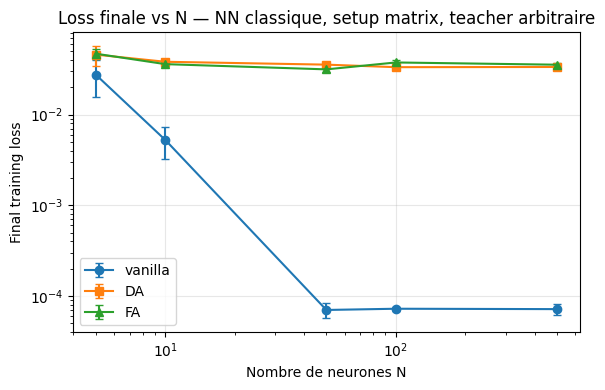

In [9]:
def plot_nn_loss_vs_N_matrix_arb(save_pdf=False):
    plot_loss_curves(
        N_VALUES,
        results_nn_matrix_arb,
        xlabel="Nombre de neurones N",
        title="Loss finale vs N — NN classique, setup matrix, teacher arbitraire",
        save_pdf=save_pdf,
    )

plot_nn_loss_vs_N_matrix_arb(save_pdf=False)

---
## 2. Réseau de neurones classique — setup **UV**

In [2]:
spaces.SETUP = spaces.make_setup_uv()
jax.clear_caches()

N_VALUES_UV = [5, 10, 50, 100, 500]
N_REPS_UV   = 3
CONFIG_UV   = {**DEFAULT_CONFIG, "T": 2.0, "gr": 5}

### 2.1 Teacher WI — setup UV

In [3]:
teacher_wi_uv = make_wi_particles()

results_nn_uv_wi = {"vanilla": [], "DA": [], "FA": []}

for N in N_VALUES_UV:
    for name in results_nn_uv_wi:
        results_nn_uv_wi[name].append([])

    for rep in range(N_REPS_UV):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train(teacher_wi_uv, N, jax.random.fold_in(key, 0), CONFIG_UV, "si")
        results_nn_uv_wi["vanilla"][-1].append(h["losses"][-1])

        h = train(teacher_wi_uv, N, jax.random.fold_in(key, 1), CONFIG_UV, "si", used_loss_fn=loss_fn_da)
        results_nn_uv_wi["DA"][-1].append(h["losses"][-1])

        h = train(teacher_wi_uv, N, jax.random.fold_in(key, 2), CONFIG_UV, "si", used_loss_fn=loss_fn_fa)
        results_nn_uv_wi["FA"][-1].append(h["losses"][-1])

    print(f"N={N} done")

W0427 11:39:27.785060 1690112 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


N=5 done


KeyboardInterrupt: 

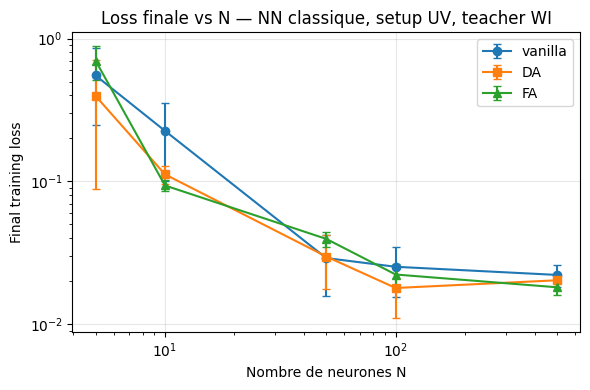

In [12]:
def plot_nn_loss_vs_N_uv_wi(save_pdf=False):
    plot_loss_curves(
        N_VALUES_UV,
        results_nn_uv_wi,
        xlabel="Nombre de neurones N",
        title="Loss finale vs N — NN classique, setup UV, teacher WI",
        save_pdf=save_pdf,
    )

plot_nn_loss_vs_N_uv_wi(save_pdf=False)

### 2.2 Teacher arbitraire — setup UV

In [13]:
teacher_arb_uv = make_arbitrary_particles()

results_nn_uv_arb = {"vanilla": [], "DA": [], "FA": []}

for N in N_VALUES_UV:
    for name in results_nn_uv_arb:
        results_nn_uv_arb[name].append([])

    for rep in range(N_REPS_UV):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train(teacher_arb_uv, N, jax.random.fold_in(key, 0), CONFIG_UV, "si")
        results_nn_uv_arb["vanilla"][-1].append(h["losses"][-1])

        h = train(teacher_arb_uv, N, jax.random.fold_in(key, 1), CONFIG_UV, "si", used_loss_fn=loss_fn_da)
        results_nn_uv_arb["DA"][-1].append(h["losses"][-1])

        h = train(teacher_arb_uv, N, jax.random.fold_in(key, 2), CONFIG_UV, "si", used_loss_fn=loss_fn_fa)
        results_nn_uv_arb["FA"][-1].append(h["losses"][-1])

    print(f"N={N} done")

N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


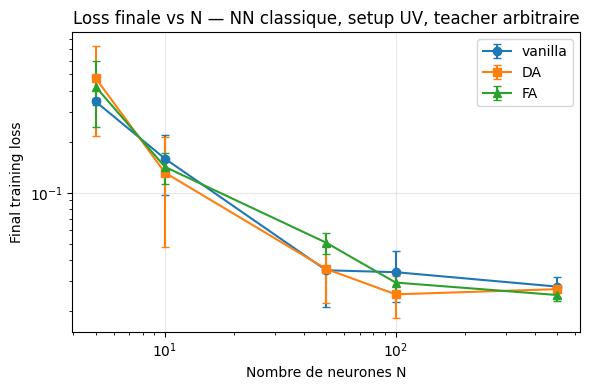

In [14]:
def plot_nn_loss_vs_N_uv_arb(save_pdf=False):
    plot_loss_curves(
        N_VALUES_UV,
        results_nn_uv_arb,
        xlabel="Nombre de neurones N",
        title="Loss finale vs N — NN classique, setup UV, teacher arbitraire",
        save_pdf=save_pdf,
    )

plot_nn_loss_vs_N_uv_arb(save_pdf=False)

---
## 3. ResNet — setup **matrix**

In [ ]:
spaces.SETUP = spaces.make_setup_matrix()
jax.clear_caches()

L_VALUES_MATRIX = [1, 10, 100, 500]
M_MATRIX        = 3
N_REPS_RN_MATRIX = 3
CONFIG_RN_MATRIX = {**DEFAULT_CONFIG_RESNET, "T": 1.0, "gr": 5, "beta": 0.0}

### 3.1 Teacher WI — setup matrix

In [18]:
teacher_wi_rn_matrix = make_wi_particles_resnet(1)

results_rn_matrix_wi = {"vanilla": [], "DA": [], "FA": []}

for L in L_VALUES_MATRIX:
    for name in results_rn_matrix_wi:
        results_rn_matrix_wi[name].append([])

    for rep in range(N_REPS_RN_MATRIX):
        key = jax.random.PRNGKey(rep * 1000 + L)

        h = train_resnet(teacher_wi_rn_matrix, M_MATRIX, L, jax.random.fold_in(key, 0), CONFIG_RN_MATRIX, "si")
        results_rn_matrix_wi["vanilla"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_wi_rn_matrix, M_MATRIX, L, jax.random.fold_in(key, 1), CONFIG_RN_MATRIX, "si", used_loss_fn=loss_fn_da_resnet)
        results_rn_matrix_wi["DA"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_wi_rn_matrix, M_MATRIX, L, jax.random.fold_in(key, 2), CONFIG_RN_MATRIX, "si", used_loss_fn=loss_fn_fa_resnet)
        results_rn_matrix_wi["FA"][-1].append(h["losses"][-1])

    print(f"L={L} done")

L=1 done
L=10 done
L=100 done
L=500 done


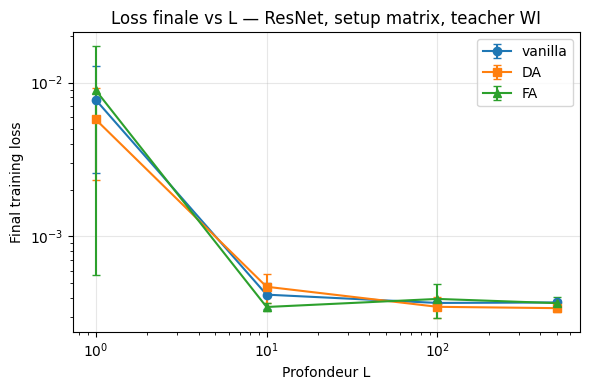

In [19]:
def plot_rn_loss_vs_L_matrix_wi(save_pdf=False):
    plot_loss_curves(
        L_VALUES_MATRIX,
        results_rn_matrix_wi,
        xlabel="Profondeur L",
        title="Loss finale vs L — ResNet, setup matrix, teacher WI",
        save_pdf=save_pdf,
    )

plot_rn_loss_vs_L_matrix_wi(save_pdf=False)

### 3.2 Teacher arbitraire — setup matrix

In [20]:
teacher_arb_rn_matrix = make_arbitrary_particles_resnet(1)

results_rn_matrix_arb = {"vanilla": [], "DA": [], "FA": []}

for L in L_VALUES_MATRIX:
    for name in results_rn_matrix_arb:
        results_rn_matrix_arb[name].append([])

    for rep in range(N_REPS_RN_MATRIX):
        key = jax.random.PRNGKey(rep * 1000 + L)

        h = train_resnet(teacher_arb_rn_matrix, M_MATRIX, L, jax.random.fold_in(key, 0), CONFIG_RN_MATRIX, "si")
        results_rn_matrix_arb["vanilla"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_arb_rn_matrix, M_MATRIX, L, jax.random.fold_in(key, 1), CONFIG_RN_MATRIX, "si", used_loss_fn=loss_fn_da_resnet)
        results_rn_matrix_arb["DA"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_arb_rn_matrix, M_MATRIX, L, jax.random.fold_in(key, 2), CONFIG_RN_MATRIX, "si", used_loss_fn=loss_fn_fa_resnet)
        results_rn_matrix_arb["FA"][-1].append(h["losses"][-1])

    print(f"L={L} done")

L=1 done
L=10 done
L=100 done
L=500 done


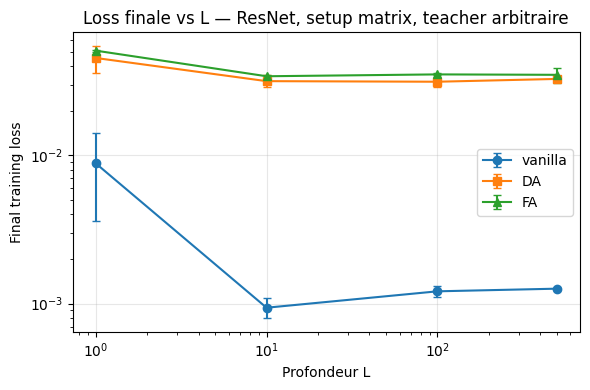

In [21]:
def plot_rn_loss_vs_L_matrix_arb(save_pdf=False):
    plot_loss_curves(
        L_VALUES_MATRIX,
        results_rn_matrix_arb,
        xlabel="Profondeur L",
        title="Loss finale vs L — ResNet, setup matrix, teacher arbitraire",
        save_pdf=save_pdf,
    )

plot_rn_loss_vs_L_matrix_arb(save_pdf=False)

---
## 4. ResNet — setup **UV**

In [ ]:
spaces.SETUP = spaces.make_setup_uv()
jax.clear_caches()

L_VALUES_UV      = [1, 10, 100, 500, 1000]
M_UV             = 2
N_REPS_RN_UV     = 3
CONFIG_RN_UV     = {**DEFAULT_CONFIG_RESNET, "T": 1.0, "gr": 5, "beta": 0.0}

### 4.1 Teacher WI — setup UV

In [32]:
teacher_wi_rn_uv = make_wi_particles_resnet(1)

results_rn_uv_wi = {"vanilla": [], "DA": [], "FA": []}

for L in L_VALUES_UV:
    for name in results_rn_uv_wi:
        results_rn_uv_wi[name].append([])

    for rep in range(N_REPS_RN_UV):
        key = jax.random.PRNGKey(rep * 1000 + L)

        h = train_resnet(teacher_wi_rn_uv, M_UV, L, jax.random.fold_in(key, 0), CONFIG_RN_UV, "si")
        results_rn_uv_wi["vanilla"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_wi_rn_uv, M_UV, L, jax.random.fold_in(key, 1), CONFIG_RN_UV, "si", used_loss_fn=loss_fn_da_resnet)
        results_rn_uv_wi["DA"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_wi_rn_uv, M_UV, L, jax.random.fold_in(key, 2), CONFIG_RN_UV, "si", used_loss_fn=loss_fn_fa_resnet)
        results_rn_uv_wi["FA"][-1].append(h["losses"][-1])

    print(f"L={L} done")

L=1 done
L=10 done
L=100 done
L=500 done
L=1000 done


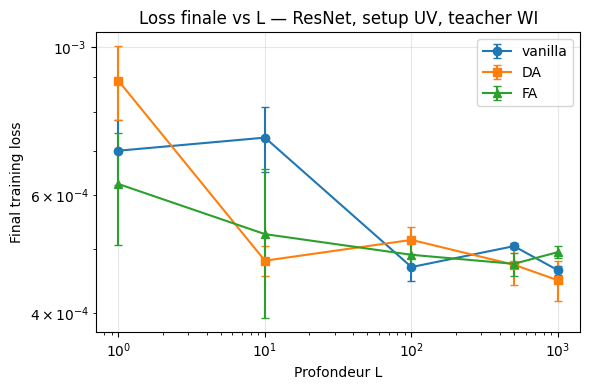

In [33]:
def plot_rn_loss_vs_L_uv_wi(save_pdf=False):
    plot_loss_curves(
        L_VALUES_UV,
        results_rn_uv_wi,
        xlabel="Profondeur L",
        title="Loss finale vs L — ResNet, setup UV, teacher WI",
        save_pdf=save_pdf,
    )

plot_rn_loss_vs_L_uv_wi(save_pdf=True)

### 4.2 Teacher arbitraire — setup UV

In [27]:
teacher_arb_rn_uv = make_arbitrary_particles_resnet(1)

results_rn_uv_arb = {"vanilla": [], "DA": [], "FA": []}

for L in L_VALUES_UV:
    for name in results_rn_uv_arb:
        results_rn_uv_arb[name].append([])

    for rep in range(N_REPS_RN_UV):
        key = jax.random.PRNGKey(rep * 1000 + L)

        h = train_resnet(teacher_arb_rn_uv, M_UV, L, jax.random.fold_in(key, 0), CONFIG_RN_UV, "si")
        results_rn_uv_arb["vanilla"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_arb_rn_uv, M_UV, L, jax.random.fold_in(key, 1), CONFIG_RN_UV, "si", used_loss_fn=loss_fn_da_resnet)
        results_rn_uv_arb["DA"][-1].append(h["losses"][-1])

        h = train_resnet(teacher_arb_rn_uv, M_UV, L, jax.random.fold_in(key, 2), CONFIG_RN_UV, "si", used_loss_fn=loss_fn_fa_resnet)
        results_rn_uv_arb["FA"][-1].append(h["losses"][-1])

    print(f"L={L} done")

L=1 done
L=10 done
L=100 done
L=500 done


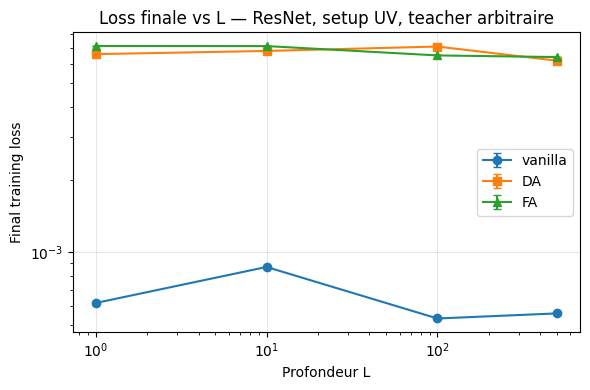

In [28]:
def plot_rn_loss_vs_L_uv_arb(save_pdf=False):
    plot_loss_curves(
        L_VALUES_UV,
        results_rn_uv_arb,
        xlabel="Profondeur L",
        title="Loss finale vs L — ResNet, setup UV, teacher arbitraire",
        save_pdf=save_pdf,
    )

plot_rn_loss_vs_L_uv_arb(save_pdf=False)

---
## 5. Courbes de loss au cours de l'entraînement

Cette section vérifie que la loss décroît bien avec le nombre de steps de SGD, pour un nombre fixé de paramètres (N = 300 pour les NN classiques, M = 5 et L = 100 pour les ResNets).  
Les courbes présentent la moyenne sur `N_REPS_CURVE = 3` répétitions avec une bande ±1 écart-type.

In [10]:
N_CURVE       = 300   # neurones pour les NN classiques
M_CURVE       = 5     # particules par couche pour les ResNets
L_CURVE       = 100   # profondeur pour les ResNets
N_REPS_CURVE  = 3
GR_CURVE      = 20    # snapshots par run (courbe lisse)

CONFIG_NN_CURVE = {**DEFAULT_CONFIG,       "T": 20.0, "gr": GR_CURVE}
CONFIG_RN_CURVE = {**DEFAULT_CONFIG_RESNET, "T": 2.0, "gr": GR_CURVE, "beta": 0.0}

### 5.1 NN classique — setup matrix (N = 300)

In [7]:
spaces.SETUP = spaces.make_setup_matrix()

teacher_curve_nn_matrix = make_wi_particles()
histories_nn_matrix = {"vanilla": [], "DA": [], "FA": []}

for rep in range(N_REPS_CURVE):
    key = jax.random.PRNGKey(rep * 100)
    h = train(teacher_curve_nn_matrix, N_CURVE, jax.random.fold_in(key, 0), CONFIG_NN_CURVE, "si")
    histories_nn_matrix["vanilla"].append(h)
    h = train(teacher_curve_nn_matrix, N_CURVE, jax.random.fold_in(key, 1), CONFIG_NN_CURVE, "si", used_loss_fn=loss_fn_da)
    histories_nn_matrix["DA"].append(h)
    h = train(teacher_curve_nn_matrix, N_CURVE, jax.random.fold_in(key, 2), CONFIG_NN_CURVE, "si", used_loss_fn=loss_fn_fa)
    histories_nn_matrix["FA"].append(h)
    print(f"rep {rep} done")

rep 0 done
rep 1 done
rep 2 done


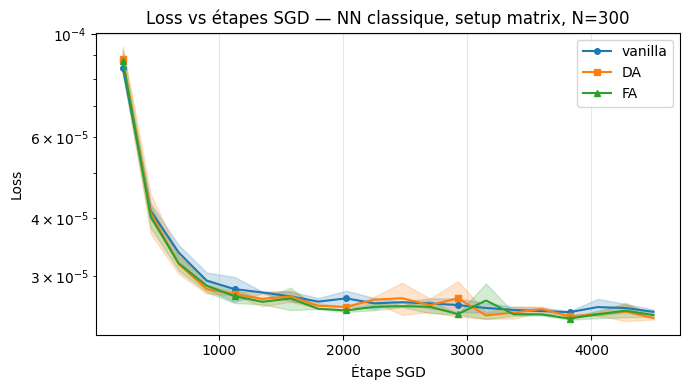

In [9]:
def plot_training_nn_matrix(save_pdf=True):
    plot_training_curves(
        histories_nn_matrix,
        title="Loss vs étapes SGD — NN classique, setup matrix, N=300",
        save_pdf=save_pdf,
    )

plot_training_nn_matrix(save_pdf=True)

### 5.2 NN classique — setup UV (N = 300)

In [11]:
spaces.SETUP = spaces.make_setup_uv()

teacher_curve_nn_uv = make_arbitrary_particles()
histories_nn_uv = {"vanilla": [], "DA": [], "FA": []}

for rep in range(N_REPS_CURVE):
    key = jax.random.PRNGKey(rep * 100)
    h = train(teacher_curve_nn_uv, N_CURVE, jax.random.fold_in(key, 0), CONFIG_NN_CURVE, "si")
    histories_nn_uv["vanilla"].append(h)
    h = train(teacher_curve_nn_uv, N_CURVE, jax.random.fold_in(key, 1), CONFIG_NN_CURVE, "si", used_loss_fn=loss_fn_da)
    histories_nn_uv["DA"].append(h)
    h = train(teacher_curve_nn_uv, N_CURVE, jax.random.fold_in(key, 2), CONFIG_NN_CURVE, "si", used_loss_fn=loss_fn_fa)
    histories_nn_uv["FA"].append(h)
    print(f"rep {rep} done")

rep 0 done
rep 1 done
rep 2 done


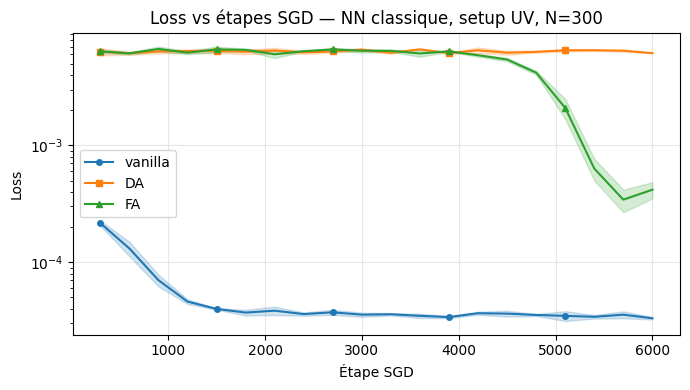

In [12]:
def plot_training_nn_uv(save_pdf=False):
    plot_training_curves(
        histories_nn_uv,
        title="Loss vs étapes SGD — NN classique, setup UV, N=300",
        save_pdf=save_pdf,
    )

plot_training_nn_uv(save_pdf=True)

### 5.3 ResNet — setup matrix (M = 5, L = 100)

In [5]:
spaces.SETUP = spaces.make_setup_matrix()

teacher_curve_rn_matrix = make_wi_particles_resnet(1)
histories_rn_matrix = {"vanilla": [], "DA": [], "FA": []}

for rep in range(N_REPS_CURVE):
    key = jax.random.PRNGKey(rep * 100)
    h = train_resnet(teacher_curve_rn_matrix, M_CURVE, L_CURVE, jax.random.fold_in(key, 0), CONFIG_RN_CURVE, "si")
    histories_rn_matrix["vanilla"].append(h)
    h = train_resnet(teacher_curve_rn_matrix, M_CURVE, L_CURVE, jax.random.fold_in(key, 1), CONFIG_RN_CURVE, "si", used_loss_fn=loss_fn_da_resnet)
    histories_rn_matrix["DA"].append(h)
    h = train_resnet(teacher_curve_rn_matrix, M_CURVE, L_CURVE, jax.random.fold_in(key, 2), CONFIG_RN_CURVE, "si", used_loss_fn=loss_fn_fa_resnet)
    histories_rn_matrix["FA"].append(h)
    print(f"rep {rep} done")

W0426 15:08:09.705828 1171544 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


rep 0 done
rep 1 done
rep 2 done


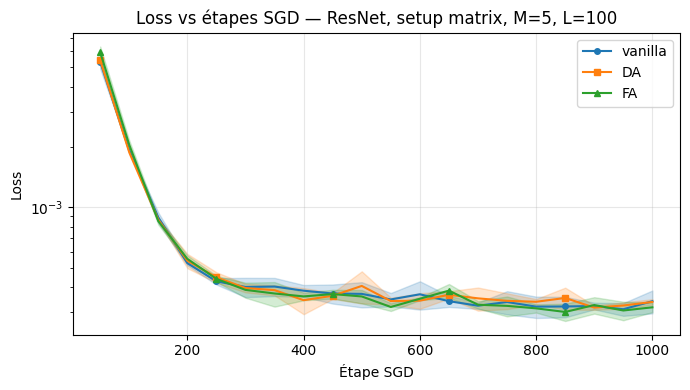

In [6]:
def plot_training_rn_matrix(save_pdf=False):
    plot_training_curves(
        histories_rn_matrix,
        title="Loss vs étapes SGD — ResNet, setup matrix, M=5, L=100",
        save_pdf=save_pdf,
    )

plot_training_rn_matrix(save_pdf=True)

### 5.4 ResNet — setup UV (M = 5, L = 100)

In [9]:
spaces.SETUP = spaces.make_setup_uv()

teacher_curve_rn_uv = make_wi_particles_resnet(1)
histories_rn_uv = {"vanilla": [], "DA": [], "FA": []}

for rep in range(N_REPS_CURVE):
    key = jax.random.PRNGKey(rep * 100)
    h = train_resnet(teacher_curve_rn_uv, M_CURVE, L_CURVE, jax.random.fold_in(key, 0), CONFIG_RN_CURVE, "si")
    histories_rn_uv["vanilla"].append(h)
    h = train_resnet(teacher_curve_rn_uv, M_CURVE, L_CURVE, jax.random.fold_in(key, 1), CONFIG_RN_CURVE, "si", used_loss_fn=loss_fn_da_resnet)
    histories_rn_uv["DA"].append(h)
    h = train_resnet(teacher_curve_rn_uv, M_CURVE, L_CURVE, jax.random.fold_in(key, 2), CONFIG_RN_CURVE, "si", used_loss_fn=loss_fn_fa_resnet)
    histories_rn_uv["FA"].append(h)
    print(f"rep {rep} done")

rep 0 done
rep 1 done
rep 2 done


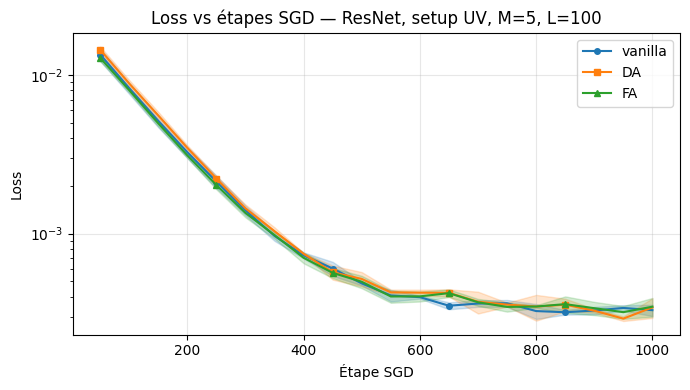

In [11]:
def plot_training_rn_uv(save_pdf=False):
    plot_training_curves(
        histories_rn_uv,
        title="Loss vs étapes SGD — ResNet, setup UV, M=5, L=100",
        save_pdf=save_pdf,
    )

plot_training_rn_uv(save_pdf=True)